# 03 - Feature engineering

Turning the cleaned table into a model-ready matrix:

1. derive a few columns the EDA suggested (`avg_monthly_charge`, `charge_ratio`,
   `num_services`, `tenure_group`);
2. rank features with mutual information to see what is worth keeping;
3. one-hot encode the categoricals and standardise the numeric columns.

The helpers are in `src/features.py` so the app can call the same code.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import CLEAN_PATH, TARGET, load_clean, split_features_target
from src.features import ENGINEERED_NUMERIC, add_features, encode_and_scale

FIG = PROJECT_ROOT / "reports" / "figures"
MODELS = PROJECT_ROOT / "models"
MODELS.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")

df = load_clean(CLEAN_PATH)
X_raw, y = split_features_target(df)
X_raw.shape

(7043, 19)

## Derived features

* `avg_monthly_charge` - `TotalCharges / tenure`, what the customer has actually been paying on
  average. It decorrelates the two charge columns (see the EDA correlation matrix).
* `charge_ratio` - `MonthlyCharges / avg_monthly_charge`. A ratio above 1 means the current bill
  is higher than the customer's historical average, i.e. their price has crept up.
* `num_services` - how many of the six add-on services are switched on.
* `tenure_group` - the same buckets used in the EDA.

In [2]:
X_fe = add_features(X_raw)
X_fe[["tenure", "MonthlyCharges", "TotalCharges"] + ENGINEERED_NUMERIC + ["tenure_group"]].head(8)

,tenure,MonthlyCharges,TotalCharges,avg_monthly_charge,num_services,charge_ratio,tenure_group
0,1,29.85,29.85,29.850000,1,1.000000,0-12
1,34,56.95,1889.50,55.573529,2,1.024768,25-48
2,2,53.85,108.15,54.075000,2,0.995839,0-12
3,45,42.30,1840.75,40.905556,3,1.034089,25-48
4,2,70.70,151.65,75.825000,0,0.932410,0-12
5,8,99.65,820.50,102.562500,3,0.971603,0-12
6,22,89.10,1949.40,88.609091,2,1.005540,13-24
7,10,29.75,301.90,30.190000,1,0.985426,0-12


In [3]:
X_fe[ENGINEERED_NUMERIC].describe().round(3)

,avg_monthly_charge,num_services,charge_ratio
count,7043.000,7043.000,7043.000
mean,64.698,2.038,1.002
std,30.271,1.848,0.051
min,0.000,0.000,0.636
25%,35.649,0.000,0.981
50%,70.300,2.000,1.000
75%,90.174,3.000,1.021
max,121.400,6.000,1.451


num_services
0    21.4
1    45.8
2    35.8
3    27.4
4    22.3
5    12.4
6     5.3
Name: Churn, dtype: float64

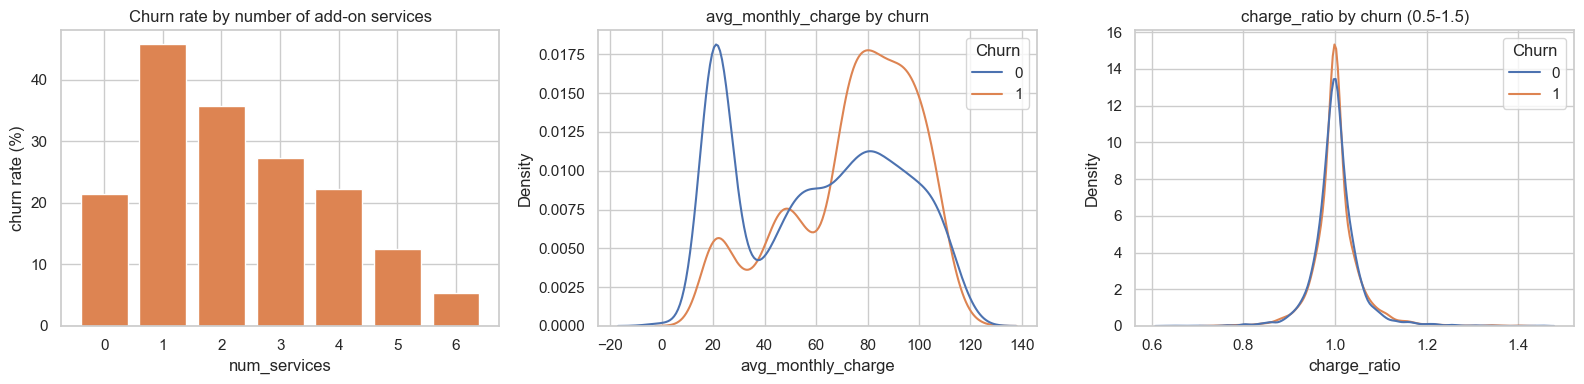

In [4]:
tmp = X_fe.assign(Churn=y.values)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
rate = tmp.groupby("num_services")["Churn"].mean() * 100
axes[0].bar(rate.index, rate.values, color="#dd8452")
axes[0].set_title("Churn rate by number of add-on services")
axes[0].set_xlabel("num_services"); axes[0].set_ylabel("churn rate (%)")
sns.kdeplot(data=tmp, x="avg_monthly_charge", hue="Churn", common_norm=False, ax=axes[1])
axes[1].set_title("avg_monthly_charge by churn")
sns.kdeplot(data=tmp[tmp["charge_ratio"].between(0.5, 1.5)], x="charge_ratio", hue="Churn", common_norm=False, ax=axes[2])
axes[2].set_title("charge_ratio by churn (0.5-1.5)")
fig.tight_layout()
fig.savefig(FIG / "10_engineered_features.png")
rate.round(1)

Churn is highest for customers with exactly one or two add-ons (46% and 36%) and falls steadily
as more services are bundled - customers with five or six add-ons churn at 12% and 5%. Customers
with zero add-ons sit in the middle because that group mixes "no internet at all" (very low
churn) with "fiber and nothing else" (high churn).

`charge_ratio` is a small but real effect: the churned density sits to the right of 1.0, meaning
churners are more often paying above their historical average.

## Encoding and scaling

`encode_and_scale` one-hot encodes every categorical column (dropping the first level of each
to avoid redundant dummies) and standardises the numeric ones. The fitted scaler is saved so the
app can apply the same transformation to new customers.

In [5]:
X, scaler = encode_and_scale(X_fe)
joblib.dump(scaler, MODELS / "scaler.joblib")
print(X.shape)
X.head()

(7043, 29)


,tenure,MonthlyCharges,TotalCharges,avg_monthly_charge,num_services,charge_ratio,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_13-24,tenure_group_25-48,tenure_group_49-72
0,-1.277445,-1.160323,-0.992611,-1.151302,-0.561776,-0.045033,0,0,1,0,...,0,0,0,1,0,1,0,0,0,0
1,0.066327,-0.259629,-0.172165,-0.301458,-0.020519,0.438306,1,0,0,0,...,0,1,0,0,0,0,1,0,1,0
2,-1.236724,-0.362660,-0.958066,-0.350966,-0.020519,-0.126229,1,0,0,0,...,0,0,0,1,0,0,1,0,0,0
3,0.514251,-0.746535,-0.193672,-0.786053,0.520738,0.620197,1,0,0,0,...,0,1,0,0,0,0,0,0,1,0
4,-1.236724,0.197365,-0.938874,0.367602,-1.103033,-1.364000,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0


In [6]:
feature_columns = X.columns.tolist()
with open(MODELS / "feature_columns.json", "w") as f:
    json.dump(feature_columns, f, indent=2)
feature_columns

['tenure',
 'MonthlyCharges',
 'TotalCharges',
 'avg_monthly_charge',
 'num_services',
 'charge_ratio',
 'gender_Male',
 'SeniorCitizen_Yes',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_Yes',
 'OnlineBackup_Yes',
 'DeviceProtection_Yes',
 'TechSupport_Yes',
 'StreamingTV_Yes',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check',
 'tenure_group_13-24',
 'tenure_group_25-48',
 'tenure_group_49-72']

## Which features carry signal?

Mutual information between each encoded column and the target. It is a quick, model-agnostic
ranking that handles the non-linear relationships (tenure, charges) better than correlation.

tenure                            0.0795
Contract_Two year                 0.0606
InternetService_Fiber optic       0.0478
MonthlyCharges                    0.0444
PaymentMethod_Electronic check    0.0439
TotalCharges                      0.0425
tenure_group_49-72                0.0394
avg_monthly_charge                0.0357
InternetService_No                0.0314
num_services                      0.0279
charge_ratio                      0.0199
PaperlessBilling_Yes              0.0192
Contract_One year                 0.0181
OnlineSecurity_Yes                0.0159
TechSupport_Yes                   0.0146
dtype: float64

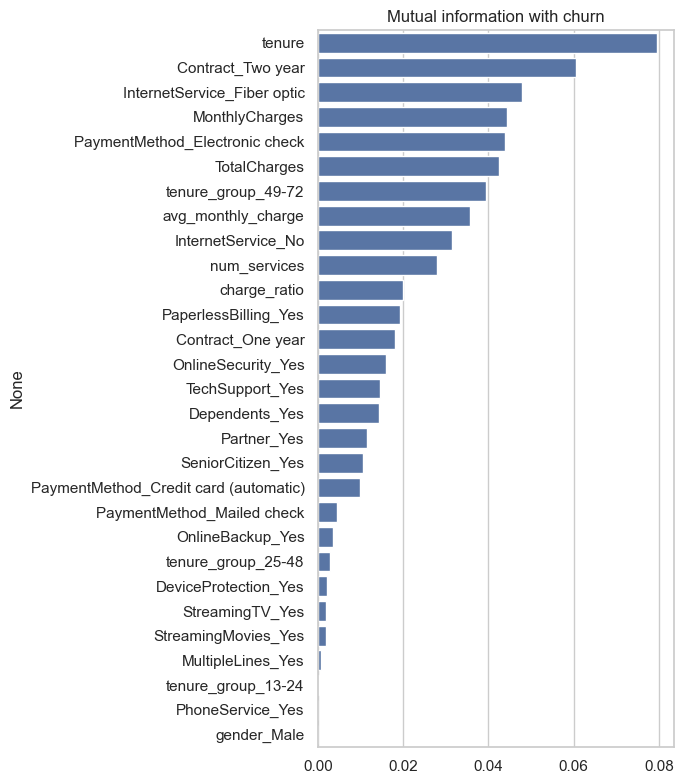

In [7]:
mi = mutual_info_classif(X, y, discrete_features=[c not in ["tenure", "MonthlyCharges", "TotalCharges"] + ENGINEERED_NUMERIC for c in X.columns], random_state=42)
mi = pd.Series(mi, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 8))
sns.barplot(x=mi.values, y=mi.index, ax=ax, color="#4c72b0")
ax.set_title("Mutual information with churn")
fig.tight_layout()
fig.savefig(FIG / "11_mutual_information.png")
mi.round(4).head(15)

The ranking agrees with the EDA: tenure-related columns, contract, the two charge columns and
internet service dominate, while `gender`, `PhoneService` and the streaming add-ons contribute
almost nothing. I keep the full set for now - tree models are robust to a few weak columns and
the total is only ~30 features - and let the explainability step confirm which ones the final
model actually uses.

In [8]:
features_path = PROJECT_ROOT / "data" / "processed" / "telco_features.csv"
X.assign(**{TARGET: y.values}).to_csv(features_path, index=False)
print("saved", features_path.relative_to(PROJECT_ROOT), X.shape)

saved data/processed/telco_features.csv (7043, 29)
